In [1]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 确保 src/ 包可被导入
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)

from config import COAL_TYPES, TRAIN_DIR, TEST_DIR
from src.data   import load_labels, load_coal_spectra
from src.submit import pack_submission

import matplotlib.pyplot as plt

In [2]:
print("=" * 60)
print("Step 1: 加载标签")
label_map, aux_map = load_labels()
print(f"  标签总数: {len(label_map)}")

Step 1: 加载标签
  标签总数: 70


In [3]:
# Get one coal type for testing
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)

In [5]:
# get the spectra data from the loaded training data
spectra = train_data['spectra']

In [10]:
spectra[0][1].shape

(7305,)

In [13]:
def plot_libs_spectra(spectra_list, start_index=0, num_to_plot=5, overlay=False):
    """
    Plots the first N elements of a LIBS spectra list.
    
    Parameters:
    -----------
    spectra_list : list of tuples
        Each tuple must be (wavelengths_array, intensity_array)
    start_index : int, default 0
        Index of the first spectrum to visualize
    num_to_plot : int, default 5
        Number of spectra from the start of the list to visualize
    overlay : bool, default False
        If True, overlays all spectra on one plot. 
        If False, creates a vertical stack of individual subplots.
    """
    # Slice the list to get only the requested number of spectra
    to_plot = spectra_list[:num_to_plot]
    n = len(to_plot)
    
    if n == 0:
        print("The spectra list is empty.")
        return

    if overlay:
        # --- Option A: Overlay all spectra on a single plot ---
        plt.figure(figsize=(12, 6))
        for i, (wvl, inten) in enumerate(to_plot):
            plt.plot(wvl, inten, label=f"Spectrum {i+1}", alpha=0.8, lw=1)
        
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Intensity (a.u.)")
        plt.title(f"LIBS Spectra Overlay (First {n} Samples)")
        plt.legend(loc="upper right")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
        
    else:
        # --- Option B: Vertical stack of subplots (Recommended for sharp LIBS peaks) ---
        fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
        
        # Ensure axes is iterable even if n=1
        if n == 1:
            axes = [axes]
            
        for i, (wvl, inten) in enumerate(to_plot):
            axes[i].plot(wvl, inten, color="crimson", lw=1)
            axes[i].set_ylabel("Intensity")
            axes[i].set_title(f"Spectrum {i+1}", fontsize=10, loc="left", pad=2)
            axes[i].grid(True, linestyle="--", alpha=0.5)
        
        # Add the shared x-axis label at the bottom
        axes[-1].set_xlabel("Wavelength (nm)")
        fig.suptitle(f"LIBS Spectra Profiles (First {n} Samples)", fontsize=14, y=0.99)
        plt.tight_layout()
        plt.show()


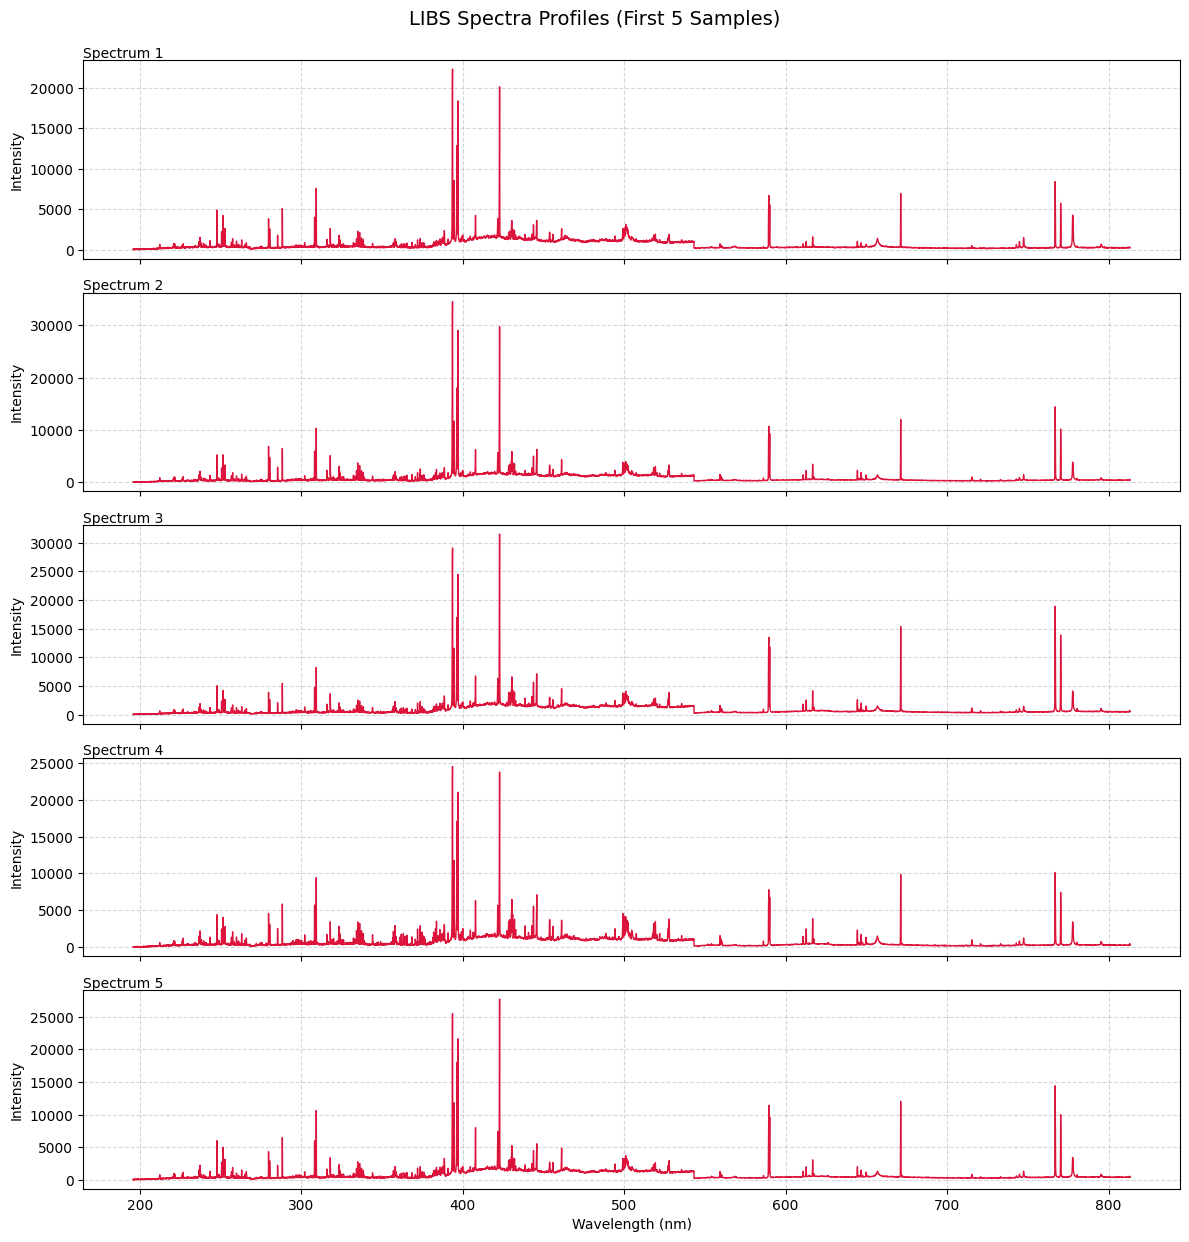

In [21]:
# Run with subplots (default)
plot_libs_spectra(spectra, start_index=0, num_to_plot=5, overlay=False)

We implement the "Asymmetric Least Squares Smoothing" by P. Eilers and H. Boelens published in 2005, which is the standard for preprocessing spectra data.

In [30]:
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_als(y, lam=1e6, p=0.005, niter=10):
    """
    Memory-optimized Asymmetric Least Squares baseline correction.
    
    Parameters:
    -----------
    y: 1D numpy array
        Raw spectrum array
    lam: float
        Smoothness parameter (try 1e5 to 1e8)
    p: float
        Asymmetry parameter (try 0.001 to 0.01)
    niter: int
        Number of iterations for the solver
        
    Returns:
    --------
    z: 1D numpy array
        Fitted baseline
    """
    L = len(y)
    
    # 1. Build the 2nd-order difference matrix natively in sparse format
    # Diagonals: [1, -2, 1], Offsets: [0, 1, 2]. Shape: (L-2, L)
    # This takes O(L) memory instead of O(L^2)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L-2, L))
    
    # 2. Precompute the penalty term outside the loop 
    # (Since lambda and D don't change, we only need to do this math once)
    H = lam * D.T.dot(D)
    
    # 3. Initialize weights
    w = np.ones(L)
    
    for i in range(niter):
        # Create sparse diagonal weight matrix
        W = sparse.diags(w, 0, shape=(L, L))
        
        # System to solve: (W + H) * z = w * y
        # Using CSC format makes the sparse solver faster
        Z = (W + H).tocsc()
        
        # Solve for the baseline
        z = spsolve(Z, w * y)
        
        # Update weights asymmetrically
        w = p * (y > z) + (1 - p) * (y < z)
        
    return z

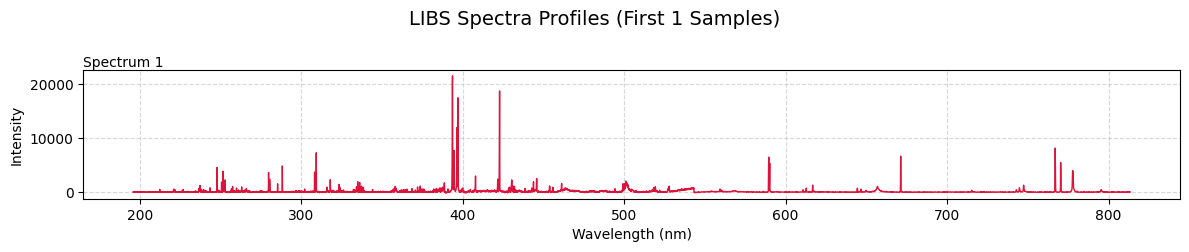

In [31]:
# try the baseline correction on the first spectrum
inten = spectra[0][1]
baseline = baseline_als(inten, lam=1e6, p=0.005)
inten_corrected = inten - baseline

plot_libs_spectra([(spectra[0][0], inten_corrected)], num_to_plot=1, overlay=False)

A note from the paper for parameter selection: "There are two parameters: $p$ for asymmetry and $\lambda$ for smoothness. Both have to be tuned to the data at hand. We found that generally $0.001 \le p \le 0.1$ is a good choice (for a signal with positive peaks) and $10^2 \le \lambda \le 10^9$, but exceptions may occur. In any case one should vary $\lambda$ on a grid that is approximately linear for $\log \lambda$."